# Documentation and workspace template for V-BReE framework.

## 1. Adding the V-BReE framework to a workspace

### Import the V-BReE module from Github
To install the V-BReE module, clone the git repository into the colab file system.

---

*If you run into problems with folder naming, you should be able to delete or rename the existing folder and then create a fresh clone*

In [ ]:
from pathlib import Path

vbree_path = Path("v_bree.py")

if not vbree_path.is_file():
  !wget https://raw.githubusercontent.com/JasonIves/V-BReE/main/v_bree.py

--2026-03-02 13:30:58--  https://raw.githubusercontent.com/JasonIves/V-BReE/main/v_bree.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16571 (16K) [text/plain]
Saving to: ‘v_bree.py’

v_bree.py           100%[===================>]  16.18K  --.-KB/s    in 0.003s  

2026-03-02 13:30:59 (4.95 MB/s) - ‘v_bree.py’ saved [16571/16571]



### Import the module

You can now import the *v_bree* module.

In [ ]:
import v_bree
import importlib

importlib.reload(v_bree)

<module 'v_bree' from '/content/v_bree.py'>

## 2. Configuring the V-BReE framework workspace

### Store inference connection API key
Modeling and inference connections often require an API key.  That key can be stored in the "Secrets" section of the sidebar, given a name, and then referenced using the *userdata* library.  This example represents a HuggingFace Inference Client key, but other services should work similarly.

Do not store API keys directly in code.

Once the token is stored you will need to give the notebook permission to access it.

In [ ]:
from google.colab import userdata

hfToken = userdata.get('HF_TOKEN')

### Define inference connection client

Define a client connection that uses the OpenAI API format.  Primary testing for this module was done using the [Hugging Face Inference Client](https://huggingface.co/docs/huggingface_hub/en/package_reference/inference_client), but other clients utilizing the OpenAI API format should work as well.


In [ ]:
from huggingface_hub import InferenceClient

client = InferenceClient(
              provider = "auto",
              api_key = hfToken
          )

## 3. Working with the V-BReE framework

### General system configuration

As usual, finishing outfitting the workspace with the necessary Python tools.


In [ ]:
import json
import re

import pandas as pd
from datasets import load_dataset

### Load data

Load the desired dataset, either from local storage, Google Drive, or a 3rd party download.  In this example the MMLU-PRO dataset will be downloaded from Hugging Face, and converted to a Pandas dataframe.

We'll load the entire validation data set for processing.

In [ ]:
dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="validation")
data = dataset.to_pandas()

sample = data

README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.14M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/42.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/12032 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/70 [00:00<?, ? examples/s]

### Configure the data for V-BReE compatibility

A V-BReE compatibile dataset has 4 key components.  Each must be provided, although the domain can be set to a dummy value without impacting ensemble processing.

- An identifier that is unique for each row. Ex: "*12893*"
- The question being asked of the ensemble.  This should be a string. Ex: "*What is 2 + 2?*"
- The possible choices, formatted as a list. Ex: "*[3, 4, 5]*"
  - Actual choices are not required. But an empty list, Ex: "*[]*", should still be submitted in the designated choices column.  When detected the ensemble will proceed in free-response mode instead of MCQ mode.
- Question domain.  Not required. For conveyence to results data. Ex: "*math*"

Any other data submitted to the V-BReE ensemble will be ignored.

In [ ]:
##REFORMAT OPTIONS COLUMN TO ENSURE LIST STRUCTURE
choice_pattern = re.compile(r"\'(.*?)\'")

sample["options"] = sample["options"].astype(str)
sample["options"] = sample["options"].apply(lambda x: re.findall(choice_pattern, x) if pd.notnull(x) else [])

display(sample)

,question_id,question,options,answer,answer_index,cot_content,category,src
0,0,The symmetric group $S_n$ has $\n\factorial{n}...,"[0, 30, 3, 10, 12, 50, 2, 100, 20, 5]",A,0,A: Let's think step by step. A characteristic ...,math,cot_lib-abstract_algebra
1,1,Let V be the set of all real polynomials p(x)....,[ST + TS is the identity map of V onto itself....,H,7,A: Let's think step by step. For a given polyn...,math,cot_lib-college_mathematics
2,2,Let A be the set of all ordered pairs of integ...,"[-5, 0, -3, -7, -4, -6, -1, -2, -9, N/A]",E,4,A: Let's think step by step. We have 12n = 22 ...,math,cot_lib-college_mathematics
3,3,A tank initially contains a salt solution of 3...,"[3 + e^-2, 2 - e^-4, 2 - e^-2, 3 + e^-4, 2 + e...",I,8,A: Let's think step by step. For all $t \in \m...,math,cot_lib-college_mathematics
4,4,A total of 30 players will play basketball at ...,"[Multiply 5 by 5 to find 25 teams., Divide 30 ...",B,1,A: Let's think step by step. We want to find t...,math,cot_lib-elementary_mathematics
...,...,...,...,...,...,...,...,...
65,65,What is the judge ad hoc?,"[Judge ad hoc is the president of the ICJ, Jud...",I,8,A: Let's think step by step. We refer to Wikip...,law,cot_lib-international_law
66,66,Functions of the law include all but which of ...,"[defining the limits of government power, regu...",I,8,A: Let's think step by step. We refer to Wikip...,law,cot_lib-jurisprudence
67,67,The ________ School of jurisprudence postulate...,"[Legal Pragmatism, Legal Formalism, Comparativ...",J,9,A: Let's think step by step. We refer to Wikip...,law,cot_lib-jurisprudence
68,68,Which word best summarizes Weber's explanation...,"[Socialism., Legitimacy., Authority., Democrac...",G,6,A: Let's think step by step. We refer to Wikip...,law,cot_lib-jurisprudence


### Instantiate Ensemble class

Create an instance of the Ensemble class, this will be the workflow manager for the V-BReE framework.

Parameters:
- *client* - Object. API inference client
- *response_type* - String, *"logic"* or *"choice"*.  Define the type of response you want from the models.  *"logic"* will return logic only, *"choice"* will return both choice and logic.
- *verbose* - Boolean, default *False*. Control display of status messages.

In [ ]:
e = v_bree.Ensemble(client = client, response_type = "choice", verbose = True)

e_gpt = v_bree.Ensemble(client = client, response_type = "choice", verbose = True)
e_qwen = v_bree.Ensemble(client = client, response_type = "choice", verbose = True)
e_llama = v_bree.Ensemble(client = client, response_type = "choice", verbose = True)

### Check for available models

Use the HfApi module to review what models are available through the Hugging Face Inference Hub.

For the V-BReE project "text-generation" is the appropriate filter.  An author filter is recommended as well, otherwise the query will return many hundreds of responses.

Commonly chosen authors are:
- openai
- google
- meta-llama
- Qwen
- mistralai
- deepseek-ai

In [ ]:
from huggingface_hub import HfApi

api = HfApi()
models = api.list_models(
    filter = "text-generation",
    author="google",
    limit=10
)
for model in models:
  print(model)

ModelInfo(id='google/gemma-3n-E4B-it-litert-lm', author=None, sha=None, created_at=datetime.datetime(2025, 6, 6, 22, 25, 42, tzinfo=datetime.timezone.utc), last_modified=None, private=False, disabled=None, downloads=39025, downloads_all_time=None, gated=None, gguf=None, inference=None, inference_provider_mapping=None, likes=368, library_name='litert-lm', tags=['litert-lm', 'text-generation', 'arxiv:1905.07830', 'arxiv:1905.10044', 'arxiv:1911.11641', 'arxiv:1904.09728', 'arxiv:1705.03551', 'arxiv:1911.01547', 'arxiv:1907.10641', 'arxiv:1903.00161', 'arxiv:2210.03057', 'arxiv:2502.12404', 'arxiv:2411.19799', 'arxiv:2009.03300', 'arxiv:2502.21228', 'arxiv:2311.12022', 'arxiv:2403.07974', 'arxiv:2108.07732', 'arxiv:2107.03374', 'license:gemma', 'region:us'], pipeline_tag='text-generation', mask_token=None, card_data=None, widget_data=None, model_index=None, config=None, transformers_info=None, trending_score=16, siblings=None, spaces=None, safetensors=None, security_repo_status=None, eval

### Add models to Ensemble

Add a string refrence for each model you want to inclue in the ensemble.  The format of these strings may vary depending on the client, and you may need to pre-load the models to your workspace if you are using them locally.

Pre-loading is not necessary for Hugging Face Inference Client.

There is no set limit to the number of models that can be added.  Prompting a single model configuration will return non-ensemble, single-prompt results.

In [ ]:
# ##ADD ALL MODELS TO THE ENSEMBLE
e.add_model("openai/gpt-oss-20b:groq")
e.add_model("Qwen/Qwen2.5-7B-Instruct:together")
e.add_model("meta-llama/Llama-3.1-8B-Instruct:cerebras")

# ##ADD EACH MODEL TO IT'S OWN PROCESSOR FOR SINGLE MODEL COMPARISON
e_gpt.add_model("openai/gpt-oss-20b:groq")
e_qwen.add_model("Qwen/Qwen2.5-7B-Instruct:together")
e_llama.add_model("meta-llama/Llama-3.1-8B-Instruct:cerebras")

### Run the V-BReE ensemble and single model comparisons

To run the ensemble, pass:
- *data* - DataFrame. Properly formatted data frame.
- *id_col* - String. Column name of the unique identifier column.
- *question_col* - String. Column name of the question text column.
- *choices_col* - String. Column name of the list-formatted choices column.
- *domain_col* - String. Column name of the question domain column.
- *model_algorithm* - String, default *"order_added"*, *"order_added"* or *"random_start"*. Flag for whether the ensemble should always start with the first model added, or start with a random model.
- *temperature* - Float, default *0.0*. Desired temperature that the models should process at.

In [ ]:
e.run(data = sample,
      id_col = "question_id",
      question_col = "question",
      choices_col = "options",
      domain_col = "category",
      model_algorithm = "random_start",
      temperature = 0.0)

Processing question_id: 0
Processing question_id: 1
Processing question_id: 2
Processing question_id: 3
Processing question_id: 4
Processing question_id: 5
Processing question_id: 6
Processing question_id: 7
Processing question_id: 8
Processing question_id: 9
Processing question_id: 10
Processing question_id: 11
Processing question_id: 12
Processing question_id: 13
Processing question_id: 14
Processing question_id: 15
Processing question_id: 16
Processing question_id: 17
Processing question_id: 18
Processing question_id: 19
Processing question_id: 20
Processing question_id: 21
Processing question_id: 22
Error decoding JSON response: Expecting ',' delimiter: line 15142 column 1 (char 23147)
Error decoding JSON response: Expecting ',' delimiter: line 15210 column 1 (char 23327)
Processing question_id: 23
Processing question_id: 24
Processing question_id: 25
Processing question_id: 26
Processing question_id: 27
Processing question_id: 28
Error decoding JSON response: Unterminated string s

In [ ]:
e_gpt.run(data = sample,
      id_col = "question_id",
      question_col = "question",
      choices_col = "options",
      domain_col = "category",
      model_algorithm = "order_added",
      temperature = 0.0)

/content/v_bree.py:141: UserWarning: Ensemble operating in single model mode: openai/gpt-oss-20b:groq, response collaboration disabled.
  warnings.warn(f"Ensemble operating in single model mode: {self.models[0]}, response collaboration disabled.")


Processing question_id: 0
Processing question_id: 1
Processing question_id: 2
Processing question_id: 3
Processing question_id: 4
Processing question_id: 5
Processing question_id: 6
Processing question_id: 7
Processing question_id: 8
Processing question_id: 9
Processing question_id: 10
Processing question_id: 11
Processing question_id: 12
Processing question_id: 13
Processing question_id: 14
Processing question_id: 15
Processing question_id: 16
Processing question_id: 17
Processing question_id: 18
Processing question_id: 19
Processing question_id: 20
Processing question_id: 21
Processing question_id: 22
Processing question_id: 23
Processing question_id: 24
Processing question_id: 25
Processing question_id: 26
Processing question_id: 27
Processing question_id: 28
Processing question_id: 29
Processing question_id: 30
Error during API call: (Request ID: req_01kjqdxkmeepbsh5rb8f9x99e6)

Bad request:
{'message': "Failed to validate JSON. Please adjust your prompt. See 'failed_generation' fo

In [ ]:
e_qwen.run(data = sample,
      id_col = "question_id",
      question_col = "question",
      choices_col = "options",
      domain_col = "category",
      model_algorithm = "order_added",
      temperature = 0.0)

/content/v_bree.py:141: UserWarning: Ensemble operating in single model mode: Qwen/Qwen2.5-7B-Instruct:together, response collaboration disabled.
  warnings.warn(f"Ensemble operating in single model mode: {self.models[0]}, response collaboration disabled.")


Processing question_id: 0
Processing question_id: 1
Processing question_id: 2
Processing question_id: 3
Processing question_id: 4
Processing question_id: 5
Processing question_id: 6
Processing question_id: 7
Processing question_id: 8
Processing question_id: 9
Processing question_id: 10
Processing question_id: 11
Processing question_id: 12
Processing question_id: 13
Processing question_id: 14
Processing question_id: 15
Processing question_id: 16
Processing question_id: 17
Processing question_id: 18
Processing question_id: 19
Processing question_id: 20
Processing question_id: 21
Processing question_id: 22
Processing question_id: 23
Processing question_id: 24
Processing question_id: 25
Processing question_id: 26
Processing question_id: 27
Processing question_id: 28
Processing question_id: 29
Processing question_id: 30
Processing question_id: 31
Processing question_id: 32
Processing question_id: 33
Processing question_id: 34
Processing question_id: 35
Processing question_id: 36
Processing 

In [ ]:
e_llama.run(data = sample,
      id_col = "question_id",
      question_col = "question",
      choices_col = "options",
      domain_col = "category",
      model_algorithm = "order_added",
      temperature = 0.0)

/content/v_bree.py:141: UserWarning: Ensemble operating in single model mode: meta-llama/Llama-3.1-8B-Instruct:cerebras, response collaboration disabled.
  warnings.warn(f"Ensemble operating in single model mode: {self.models[0]}, response collaboration disabled.")


Processing question_id: 0
Processing question_id: 1
Processing question_id: 2
Error decoding JSON response: Unterminated string starting at: line 1 column 29 (char 28)
Processing question_id: 3
Processing question_id: 4
Processing question_id: 5
Processing question_id: 6
Processing question_id: 7
Processing question_id: 8
Processing question_id: 9
Processing question_id: 10
Processing question_id: 11
Processing question_id: 12
Processing question_id: 13
Processing question_id: 14
Processing question_id: 15
Processing question_id: 16
Processing question_id: 17
Processing question_id: 18
Processing question_id: 19
Processing question_id: 20
Processing question_id: 21
Processing question_id: 22
Processing question_id: 23
Processing question_id: 24
Processing question_id: 25
Processing question_id: 26
Processing question_id: 27
Processing question_id: 28
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Processing question_id: 29
Processing question_

## Review the ensemble results

Retrieve the results from the ensemble.
- *selected_only* - Boolean. Flag indicating if you want the selected responses returned, or all responses processed by the ensemble.

In [ ]:
results = e.get_results(selected_only = False)
results.to_csv("v-bree_mmlupro_validation_20260228.csv")

gpt_results = e_gpt.get_results(selected_only = False)
gpt_results.to_csv("gpt_mmlupro_validation_20260228.csv")

qwen_results = e_qwen.get_results(selected_only = False)
qwen_results.to_csv("qwen_mmlupro_validation_20260228.csv")

llama_results = e_llama.get_results(selected_only = False)
llama_results.to_csv("llama_mmlupro_validation_20260228.csv")

### Process the results as needed

Once the results are returned you can write to csv, check correctness of responses, generate plots, summary statistics, etc. - as with any other data.

[np.float64(0.6979310344827586), np.float64(0.7142857142857143), np.float64(0.6285714285714286), np.float64(0.3142857142857143)]


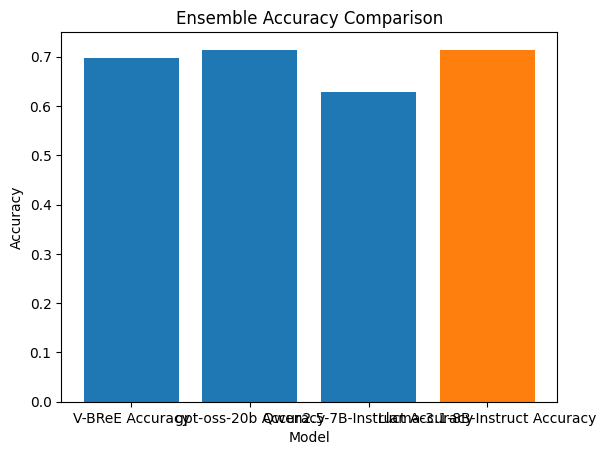

<Figure size 1000x600 with 0 Axes>

In [ ]:
merged = pd.merge(results, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")

gpt_merged = pd.merge(gpt_results, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")
qwen_merged = pd.merge(qwen_results, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")
llama_merged = pd.merge(llama_results, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")

import matplotlib.pyplot as plt

accuracy = []
accuracy.append((merged["answer"] == merged["selected_choice"]).mean())
accuracy.append((gpt_merged["answer"] == gpt_merged["selected_choice"]).mean())
accuracy.append((qwen_merged["answer"] == qwen_merged["selected_choice"]).mean())
accuracy.append((llama_merged["answer"] == llama_merged["selected_choice"]).mean())

print(accuracy)

plt.bar(x = ["V-BReE Accuracy", "gpt-oss-20b Accuracy", "Qwen2.5-7B-Instruct Accuracy", "Llama-3.1-8B-Instruct Accuracy"], height = accuracy)
plt.bar(x = ["Llama-3.1-8B-Instruct Accuracy"], height = accuracy)
plt.title("Ensemble Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.figure(figsize=(10, 6))
plt.show()

## 4. Other Available V-BReE Methods

A variety of other methodsfor getting and setting various ensemble parameters are also available.

#### Setters:
*set_instructions(instructions: str)* - Set primary instructional prompt text.

*set_mcq_instructions(mcq_instructions: str)* - Set MCQ specific instructional prompt text.

*set_variance_threshold(threshold: float)* - Set the variance threshold starting value.

*set_variance_scaling_factor(scaling_factor: float)* - Set the variance threshold exponential scaling factor.

*set_variance_confidence_coefficient(coefficient: float)* - Set the variance confidence coefficient, for parameterizing the variance in the confidence formula.
    
*set_mean_confidence_coefficient(coefficient: float)* - Set the mean confidence coefficient, for parameterizing the mean in the confidence formula.
    
*set_n_confidence_coefficient(coefficient: float)* - Set the response count confidence coefficient, for parameterizing the response count in the confidence formula.


#### Getters:
*get_instructions()* - Get the current primary instructional prompt text.
    
*get_mcq_instructions()* - Get the current mcq specific instructional prompt text.
       
*get_variance_threshold()* - Get the current variance threshold starting value.

*get_variance_scaling_factor()* - Get the current variance scaling factor.
    
*get_confidence_coefficients()* - Get a dict of variance, mean and response count confidence coefficients.

In [ ]:
print(f"main instruction text: {e.get_instructions()}\n")
print(f"mcq instruction text: {e.get_mcq_instructions()}\n")
print(f"variance threshold: {e.get_variance_threshold()}\n")
print(f"variance scaling factor: {e.get_variance_scaling_factor()}\n")
print(f"confidence coefficients: {e.get_confidence_coefficients()}")